In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [45]:
# This is the sample 2 dimensional data we are going to reduce

X = np.matrix([2.5, 0.5, 2.2, 1.9, 3.1, 2.3, 2, 1, 1.5, 1.1  ])

Y = np.matrix([2.4, 0.7, 2.9, 2.2, 3.0, 2.7, 1.6, 1.1, 1.6, 0.9])

Data = np.r_[X,Y]

In [46]:
X_mean = np.mean(X)
Y_mean = np.mean(Y)

X_centered = X - X_mean
Y_centered = Y - Y_mean

Data_centered = np.r_[X_centered, Y_centered]

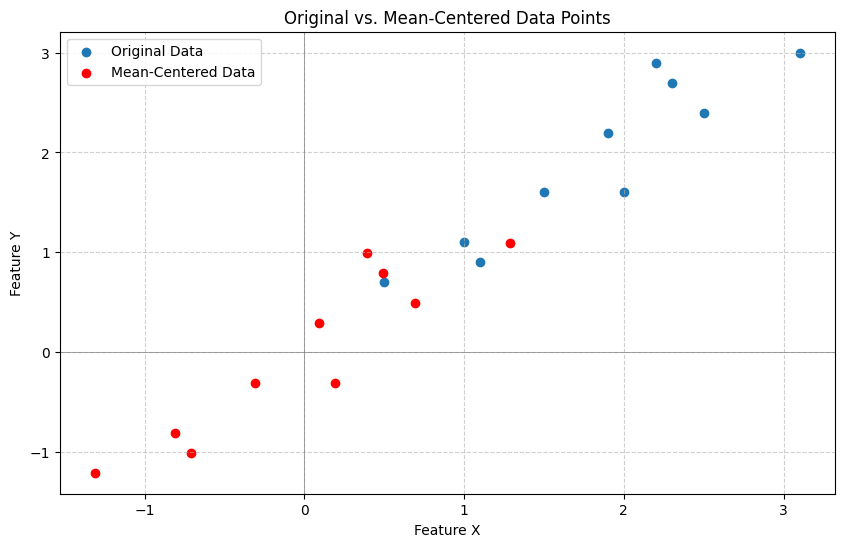

In [47]:
plt.figure(figsize=(10, 6))
plt.scatter(np.array(X)[0], np.array(Y)[0], label="Original Data")
plt.xlabel("Feature X")
plt.ylabel("Feature Y")
plt.scatter(np.array(X_centered)[0], np.array(Y_centered)[0], color='r', label="Mean-Centered Data")
plt.title("Original vs. Mean-Centered Data Points")
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [48]:
CoV_unscaled = np.matmul(Data_centered, Data_centered.T)

N = Data_centered.shape[1]
CoV_scaled = CoV_unscaled / (N - 1)

In [49]:
EVals, EVecs = np.linalg.eigh(CoV_scaled)

print("Eigen-values :", EVals)

print("Eigen-vectors :", EVecs)

Eigen-values : [0.0490834  1.28402771]
Eigen-vectors : [[-0.73517866  0.6778734 ]
 [ 0.6778734   0.73517866]]


In [50]:
EVecs = np.flip(EVecs, axis=1)

EVals = np.flip(EVals)

print("Eigen-Values :", EVals)

print("Eigen-Vectors :", EVecs)

Eigen-Values : [1.28402771 0.0490834 ]
Eigen-Vectors : [[ 0.6778734  -0.73517866]
 [ 0.73517866  0.6778734 ]]


In [52]:
print(np.dot(EVecs[:,0].T,EVecs[:,1]))

[[0.]]


(np.float64(-1.6173930421976976),
 np.float64(1.6173930421976976),
 np.float64(-1.6173930421976976),
 np.float64(1.6173930421976976))

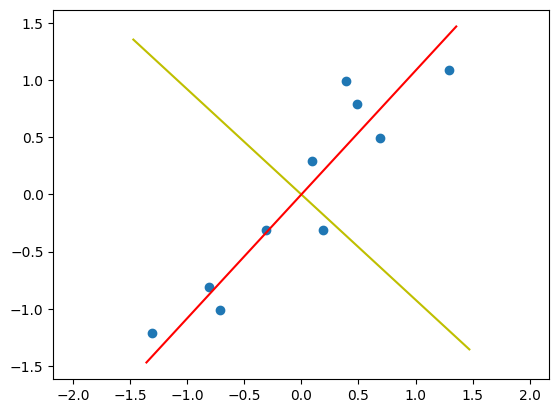

In [59]:
plt.scatter(np.array(X_centered)[0], np.array(Y_centered)[0])

plt.plot([-EVecs[0,1]*2, EVecs[0,1]*2], [-EVecs[1,1]*2, EVecs[1,1]*2], 'y')

plt.plot([-EVecs[0,0]*2, EVecs[0,0]*2], [-EVecs[1,0]*2, EVecs[1,0]*2], 'r')

plt.axis('equal')